# Main-text figures

Each figure is one self-contained cell: it imports what it needs, loads saved data from
`data/generated/`, and writes a PDF to `figures/`. No simulations run here; each caption
names the generator that produces its data (`make data` runs them all).

Each cell is mirrored verbatim in the script named on its first line, so `make figures`
produces the same PDFs without Jupyter. After editing a cell here, run `make figure-scripts`.

## Figure 1: Agents starting from the same strategy move different distances when learning rates vary

Data: No data.

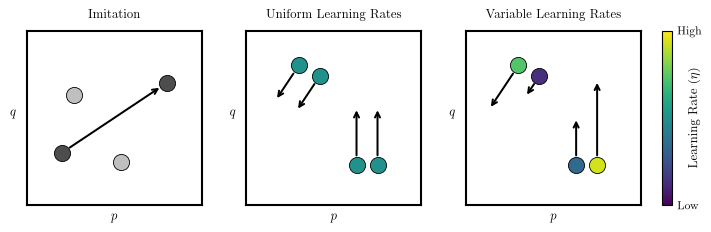

In [1]:
# Figure 1 (scripts/figures/fig01_conceptual_comparison.py)
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

from reactive_learning.paths import FIGURES_DIR
from reactive_learning.plotting import FIGURE_WIDTH, configure_paper_style

# Illustrative values.
# Each arrow is rate * gradient; the two agents in a pair share a
# gradient. Agents: bottom-left, bottom-right, top-left, top-right.
STARTS = np.array([(0.63, 0.23), (0.75, 0.23), (0.30, 0.80), (0.42, 0.74)])
DIRECTIONS = np.array([(0, 1), (0, 1), (-0.12, -0.18), (-0.12, -0.18)])
GRADIENTS = np.repeat([1.65, 1.2], 2)  # bottom pair, top pair
UNIFORM_RATE = 0.2
VARIABLE_RATES = [0.165, 0.295, 0.25, 0.12]
NORM = mpl.colors.Normalize(0.09, 0.31)

configure_paper_style()
fig, axes = plt.subplots(1, 3, figsize=(FIGURE_WIDTH, 2.2))
fig.get_layout_engine().set(wspace=0.12)
for ax in axes:
    ax.set(xlim=(0, 1), ylim=(0, 1), xticks=[], yticks=[], box_aspect=1)
    ax.set_xlabel(r"$p$")
    ax.set_ylabel(r"$q$", rotation=0, labelpad=10)
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)


def agent(ax, point, color):
    ax.scatter(*point, color=color, s=135, zorder=3, edgecolor="k", linewidth=0.6)


def arrow(ax, start, end, **kwargs):
    props = {"arrowstyle": "->", "linewidth": 1.44, "shrinkA": 7, "color": "k", **kwargs}
    ax.annotate("", xy=end, xytext=start, arrowprops=props)


imitation = [(0.2, 0.3), (0.8, 0.7), (0.27, 0.63), (0.54, 0.25)]
for point, color in zip(imitation, ["0.3", "0.3", "0.75", "0.75"], strict=True):
    agent(axes[0], point, color)
arrow(axes[0], imitation[0], imitation[1], shrinkB=6.3)
axes[0].set_title("Imitation", pad=9)

gradients = DIRECTIONS / np.hypot(*DIRECTIONS.T)[:, None] * GRADIENTS[:, None]
for ax, title, rates in [(axes[1], "Uniform Learning Rates", [UNIFORM_RATE] * 4),
                         (axes[2], "Variable Learning Rates", VARIABLE_RATES)]:
    for start, gradient, rate in zip(STARTS, gradients, rates, strict=True):
        agent(ax, start, plt.cm.viridis(NORM(rate)))
        arrow(ax, start, start + rate * gradient)
    ax.set_title(title, pad=9)

bar = fig.colorbar(plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=NORM),
                   cax=axes[2].inset_axes([1.12, 0, 0.06, 1]))
bar.set_ticks([NORM.vmin, NORM.vmax], labels=["Low", "High"])
bar.ax.tick_params(length=0)
bar.set_label(r"Learning Rate ($\eta$)", labelpad=-10)

fig.savefig(FIGURES_DIR / "cartoon.pdf")

## Figure 2: Trajectories of every agent's reciprocity $p$ and forgiveness $q$

Data: `agent_uniform.npz`, `agent_variable.npz` from `scripts/generate/agent_main_data.py`.

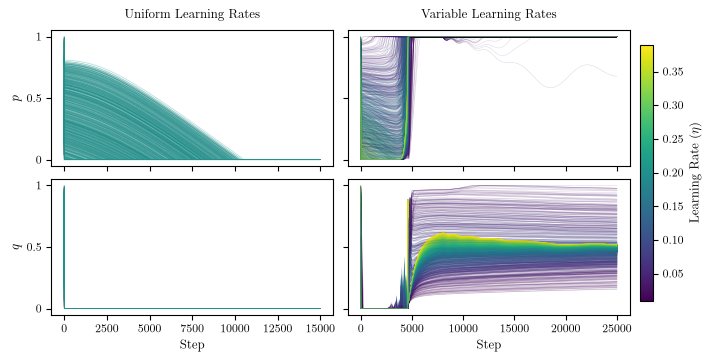

In [2]:
# Figure 2 (scripts/figures/fig02_agent_trajectories.py)
import matplotlib.pyplot as plt
import numpy as np

from reactive_learning.paths import DATA_DIR, FIGURES_DIR
from reactive_learning.plotting import FIGURE_WIDTH, add_eta_colorbar, configure_paper_style

configure_paper_style()
fig, axes = plt.subplots(2, 2, figsize=(FIGURE_WIDTH, 3.5), sharex="col", sharey=True)
norm = plt.Normalize(vmin=0.01, vmax=0.39)
cmap = plt.get_cmap("viridis")

for column, (regime, title) in enumerate(
    [("uniform", "Uniform Learning Rates"), ("variable", "Variable Learning Rates")]
):
    with np.load(DATA_DIR / f"agent_{regime}.npz") as data:
        steps, agents, eta = data["steps"], data["agents"], data["eta"]
    for row, label in enumerate(["$p$", "$q$"]):
        ax = axes[row, column]
        lines = ax.plot(steps, agents[:, :, row], alpha=0.18, linewidth=0.35)
        for line, rate in zip(lines, eta, strict=True):
            line.set_color(cmap(norm(rate)))
        ax.set_ylim(-0.05, 1.05)
        ax.set_yticks([0, 0.5, 1], ["0", "0.5", "1"])
        if row == 0:
            ax.set_title(title, pad=9)
        else:
            ax.set_xlabel("Step")
        if column == 0:
            ax.set_ylabel(label)

add_eta_colorbar(fig, axes)
fig.savefig(FIGURES_DIR / "agent_based_dist.pdf", dpi=300)

## Figure 3: Four stages of a population with variable learning rates

Data: `agent_variable.npz` from `scripts/generate/agent_main_data.py`.

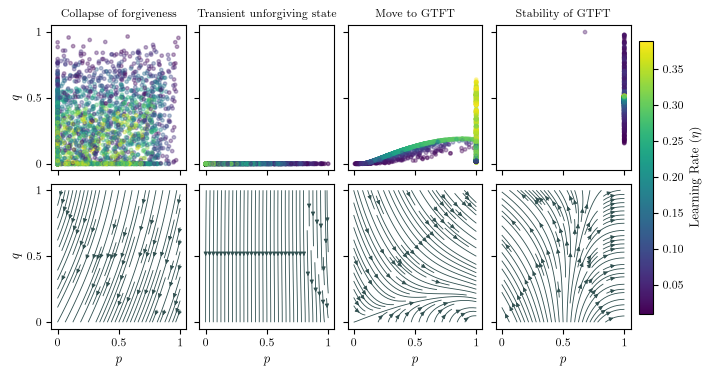

In [3]:
# Figure 3 (scripts/figures/fig03_stages_and_gradient_fields.py)
import numpy as np

from reactive_learning.paths import DATA_DIR, FIGURES_DIR
from reactive_learning.plotting import configure_paper_style, plot_agents_and_avg_field_2x4

STAGES = {
    5: "Collapse of forgiveness",
    300: "Transient unforgiving state",
    4609: "Move to GTFT",
    25000: "Stability of GTFT",
}

with np.load(DATA_DIR / "agent_variable.npz") as data:
    steps = data["steps"].tolist()
    snapshots = [data["agents"][steps.index(step)] for step in STAGES]
    eta, b, c = data["eta"], float(data["b"]), float(data["c"])

configure_paper_style()
fig, axs = plot_agents_and_avg_field_2x4(snapshots, STAGES.values(), eta, b=b, c=c)
fig.savefig(FIGURES_DIR / "steps_with_streams.pdf")